# 1: Dog vs Cat Classification

# IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

2026-06-23 10:09:49.828646: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782209390.280454      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782209390.400192      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782209391.508264      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782209391.508310      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782209391.508312      58 computation_placer.cc:177] computation placer alr

In [2]:
import tensorflow as tf

print(tf.__version__)

2.19.0


In [3]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 2


# LOAD DATASET

In [4]:
import os

print(os.listdir('/kaggle/input'))

['datasets']


In [5]:
import os

print(os.listdir('/kaggle/input/datasets'))

['anthonytherrien', 'moltean']


In [6]:
import os

print(os.listdir('/kaggle/input/datasets/anthonytherrien'))

['dog-vs-cat']


In [7]:
import os

print(os.listdir('/kaggle/input/datasets/anthonytherrien/dog-vs-cat'))

['animals']


In [8]:
import os

print(os.listdir('/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals'))

['dog', 'cat']


In [9]:
data_path = ("/kaggle/input/datasets/anthonytherrien/dog-vs-cat")
print(os.listdir("/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals"))
print(os.listdir("/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/cat"))
print(os.listdir("/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog"))


['dog', 'cat']
['00246-200124556.png', '00102-200124412.png', '00034-200124344.png', '00350-200124660.png', '00343-200124653.png', '00119-200124429.png', '00396-200124706.png', '00494-200124804.png', '00397-200124707.png', '00025-200124335.png', '00056-200124366.png', '00066-200124376.png', '00460-200124770.png', '00318-200124628.png', '00062-200124372.png', '00419-200124729.png', '00434-200124744.png', '00441-200124751.png', '00489-200124799.png', '00273-200124583.png', '00173-200124483.png', '00289-200124599.png', '00473-200124783.png', '00331-200124641.png', '00121-200124431.png', '00208-200124518.png', '00114-200124424.png', '00055-200124365.png', '00341-200124651.png', '00346-200124656.png', '00150-200124460.png', '00254-200124564.png', '00100-200124410.png', '00124-200124434.png', '00135-200124445.png', '00097-200124407.png', '00380-200124690.png', '00420-200124730.png', '00466-200124776.png', '00220-200124530.png', '00351-200124661.png', '00445-200124755.png', '00006-4122619879.

In [10]:
data_path = '/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals'

# DATA PREPROCESSING

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [12]:
train_data = datagen.flow_from_directory(
    data_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 800 images belonging to 2 classes.


In [13]:
val_data = datagen.flow_from_directory(
    data_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 200 images belonging to 2 classes.


# MODEL ARCHITECTURE(CNN)

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

I0000 00:00:1782209413.476233      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782209413.482242      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# MODEL COMPILATION 

In [15]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# MODEL TRAINING

In [16]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10


I0000 00:00:1782209419.478505     139 service.cc:152] XLA service 0x7eaec0004d10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782209419.478565     139 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782209419.478571     139 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782209420.016006     139 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-23 10:10:22.424377: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-23 10:10:22.572322: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 1/25 ━━━━━━━━━━━━━━━━━━━━ 2:59 7s/step - accuracy: 0.4688 - loss: 0.6906

I0000 00:00:1782209424.749415     139 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 962ms/step - accuracy: 0.5688 - loss: 0.7204 - val_accuracy: 0.7900 - val_loss: 0.6000
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 464ms/step - accuracy: 0.7700 - loss: 0.5264 - val_accuracy: 0.8550 - val_loss: 0.3955
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 469ms/step - accuracy: 0.8512 - loss: 0.3698 - val_accuracy: 0.9050 - val_loss: 0.2914
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 458ms/step - accuracy: 0.9075 - loss: 0.2542 - val_accuracy: 0.9400 - val_loss: 0.2002
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 464ms/step - accuracy: 0.9488 - loss: 0.1538 - val_accuracy: 0.9100 - val_loss: 0.1906
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 456ms/step - accuracy: 0.9600 - loss: 0.1132 - val_accuracy: 0.9500 - val_loss: 0.1541
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 460ms/step - accuracy: 0.9737 - loss: 0.0700 - val_accuracy: 0.9600 - val_loss: 0.0985
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 455ms/step - accuracy: 0.9837 - loss: 0.0584 - val_accuracy: 0.955

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,914,309 (37.82 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,609,540 (25.21 MB)

# ACCURACY AND LOSS GRAPH

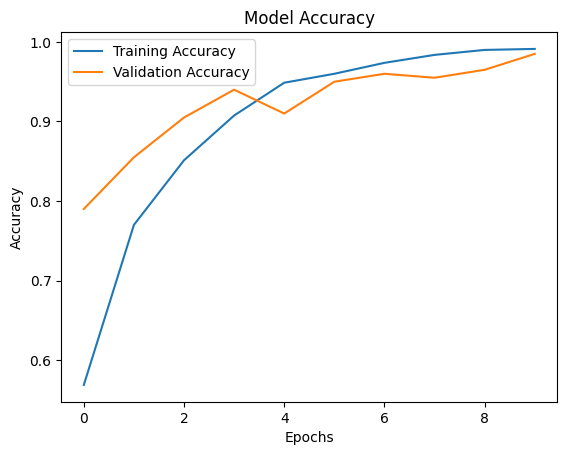

In [18]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

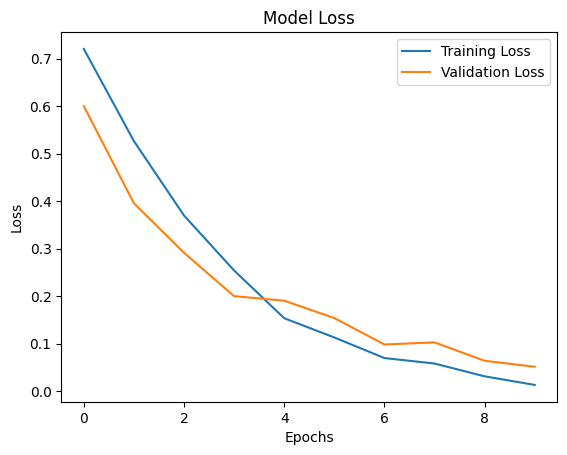

In [19]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# PREDICTION(TESTING)

In [20]:
import os
import random

cat_path = data_path + "/cat"
dog_path = data_path + "/dog"

img_name = random.choice(os.listdir(cat_path)) 
img_path = cat_path + "/" + img_name

print(img_path)

/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/cat/00062-200124372.png


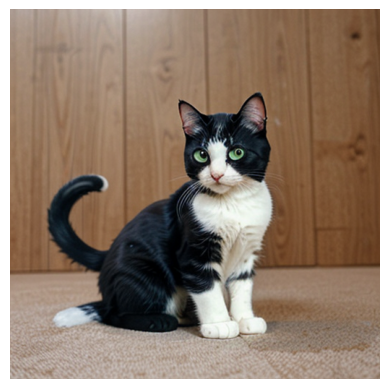

In [21]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread(img_path)

plt.imshow(img)
plt.axis('off')
plt.show()

In [22]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step
Cat


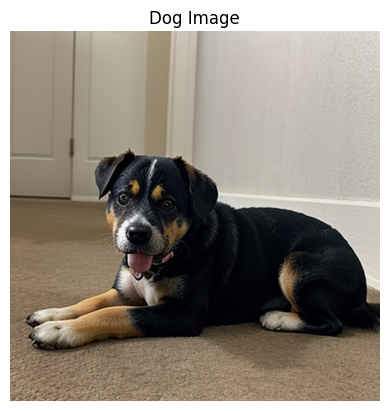

In [23]:
dog_img = random.choice(os.listdir(dog_path))
dog_img_path = dog_path + "/" + dog_img

img = mpimg.imread(dog_img_path)
plt.imshow(img)
plt.title("Dog Image")
plt.axis('off')
plt.show()

In [24]:
img = image.load_img(dog_img_path, target_size=(128,128))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Dog (Correct Prediction)")
else:
    print("Cat (Wrong Prediction)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Dog (Correct Prediction)


# SUMMARY

This project is a Dog vs Cat image classification system built using a Convolutional Neural Network (CNN). The main objective of the project is to train a deep learning model that can accurately identify whether a given image contains a dog or a cat. The dataset consists of two categories, cat and dog images, which are organized into separate folders. These images are preprocessed before training by resizing them to a fixed size of 128×128 pixels and normalizing pixel values using rescaling (1./255) so that the model can learn more efficiently. The dataset is also split into training and validation sets to evaluate the model’s performance during training.

The CNN model is built using multiple layers including Conv2D, MaxPooling, Flatten, Dense, and Dropout layers. The Conv2D layers are responsible for extracting important features from images such as edges, shapes, and facial patterns, while MaxPooling reduces the spatial size to make computation more efficient. The Flatten layer converts the extracted features into a one-dimensional array, which is then passed through Dense layers for classification. A Dropout layer is used to prevent overfitting and improve generalization. The final output layer uses a sigmoid activation function to predict whether the image belongs to class 0 (cat) or class 1 (dog).

The model is compiled using the Adam optimizer, binary cross-entropy loss function, and accuracy as the evaluation metric. It is trained for multiple epochs using the training dataset while validating its performance on unseen validation data. After training, the model achieves good accuracy, and performance is visualized using accuracy and loss graphs. Finally, the trained model is able to correctly classify new images as either a dog or a cat, demonstrating the effectiveness of CNN in image classification tasks.

# 2 : TRANSFER LEARNING

# IMPORT LIBRARIES

In [25]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model

from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')


# LOAD DATASET

In [26]:
import os

base_path = "/kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360"

train_path = base_path + "/Training"
test_path  = base_path + "/Test"

print("Base folders:", os.listdir(base_path))

print("\nTrain path exists:", os.path.exists(train_path))
print("Test path exists:", os.path.exists(test_path))

print("\nTrain classes count:", len(os.listdir(train_path)))
print("Test classes count:", len(os.listdir(test_path)))

print("\nSample train folders:", os.listdir(train_path)[:5])

Base folders: ['LICENSE', 'Training', 'README.md', 'Test']

Train path exists: True
Test path exists: True

Train classes count: 260
Test classes count: 260

Sample train folders: ['Melon Piel de Sapo 1', 'Dates 1', 'Avocado Black 2', 'Nectarine Flat 2', 'Apple Crimson Snow 1']


In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 64

train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [28]:
img_size = (224, 224)

In [29]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=64,
    class_mode='categorical',
    subset='training'
)

val_data = train_gen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)




Found 109865 images belonging to 260 classes.
Found 27356 images belonging to 260 classes.


In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

Found 45724 images belonging to 260 classes.


# Build ResNet50 Model

In [34]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model

**load pretrained model**

In [35]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**freeze model**

In [36]:
for layer in base_model.layers:
    layer.trainable = False

**custom model**

In [37]:
x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

**Compile model**

In [38]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**train the model**

In [39]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=3,
    verbose=1
)

Epoch 1/3
1717/1717 ━━━━━━━━━━━━━━━━━━━━ 1428s 822ms/step - accuracy: 0.0068 - loss: 5.5471 - val_accuracy: 0.0071 - val_loss: 5.5156
Epoch 2/3
1717/1717 ━━━━━━━━━━━━━━━━━━━━ 461s 268ms/step - accuracy: 0.0066 - loss: 5.5114 - val_accuracy: 0.0072 - val_loss: 5.5072
Epoch 3/3
1717/1717 ━━━━━━━━━━━━━━━━━━━━ 464s 270ms/step - accuracy: 0.0069 - loss: 5.5073 - val_accuracy: 0.0072 - val_loss: 5.5055


**tarining result graph**

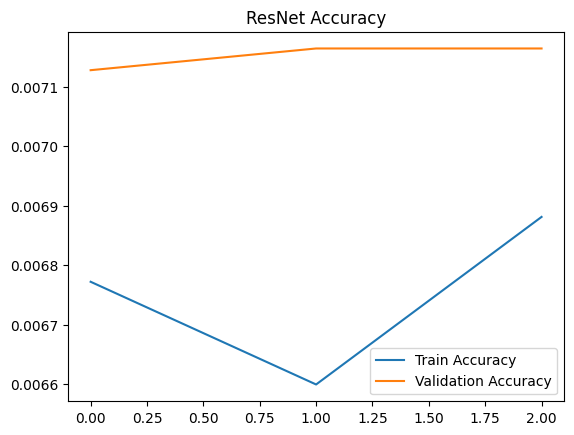

In [40]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("ResNet Accuracy")
plt.legend()
plt.show()

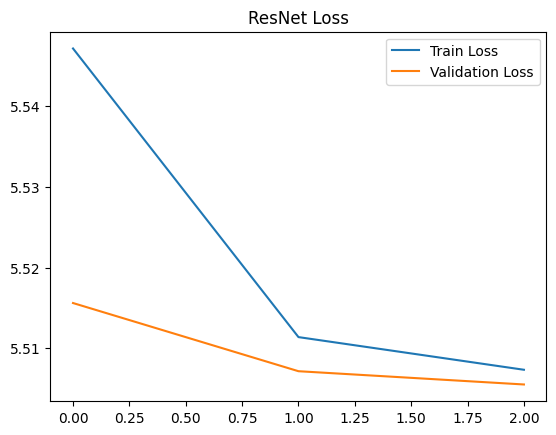

In [41]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("ResNet Loss")
plt.legend()
plt.show()

**Model evaluation**

In [42]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

715/715 ━━━━━━━━━━━━━━━━━━━━ 466s 652ms/step - accuracy: 0.0072 - loss: 5.5072
Test Accuracy: 0.007173475809395313


**Prediction**

In [43]:
predictions = model.predict(test_data)
print(predictions.shape)

715/715 ━━━━━━━━━━━━━━━━━━━━ 159s 217ms/step
(45724, 260)


# VGG 16

In [44]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model

**Load pretrained model**

In [45]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**freeze base layer**

In [46]:
for layer in base_model.layers:
    layer.trainable = False

**custom classifier**

In [48]:
x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(train_data.num_classes, activation='softmax')(x)

model_vgg = Model(inputs=base_model.input, outputs=output)

**compile model**

In [49]:
model_vgg.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**tain model**

In [50]:
history_vgg = model_vgg.fit(
    train_data,
    validation_data=val_data,
    epochs=3,
    verbose=1
)

Epoch 1/3
1717/1717 ━━━━━━━━━━━━━━━━━━━━ 776s 435ms/step - accuracy: 0.0150 - loss: 5.2150 - val_accuracy: 0.0462 - val_loss: 4.8017
Epoch 2/3
1717/1717 ━━━━━━━━━━━━━━━━━━━━ 746s 434ms/step - accuracy: 0.0179 - loss: 5.0666 - val_accuracy: 0.0525 - val_loss: 4.6725
Epoch 3/3
1717/1717 ━━━━━━━━━━━━━━━━━━━━ 737s 429ms/step - accuracy: 0.0195 - loss: 5.0327 - val_accuracy: 0.0504 - val_loss: 4.5944


**Evaluate model**

In [51]:
test_loss_vgg, test_acc_vgg = model_vgg.evaluate(test_data)

print("VGG Test Loss:", test_loss_vgg)
print("VGG Test Accuracy:", test_acc_vgg)

715/715 ━━━━━━━━━━━━━━━━━━━━ 243s 339ms/step - accuracy: 0.0579 - loss: 4.5495
VGG Test Loss: 4.549534797668457
VGG Test Accuracy: 0.05786895379424095


**Accuracy garph**

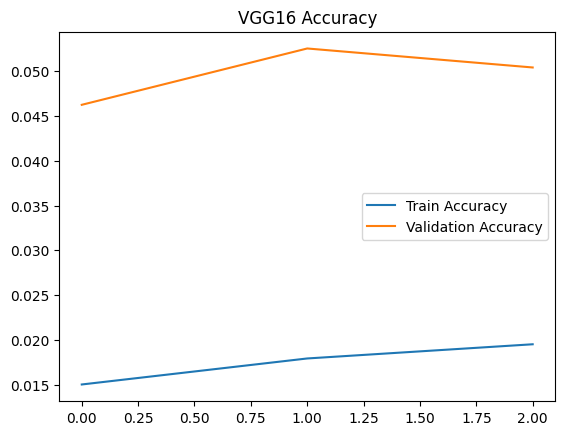

In [52]:
import matplotlib.pyplot as plt

plt.plot(history_vgg.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Validation Accuracy')
plt.title("VGG16 Accuracy")
plt.legend()
plt.show()

**loss graph**

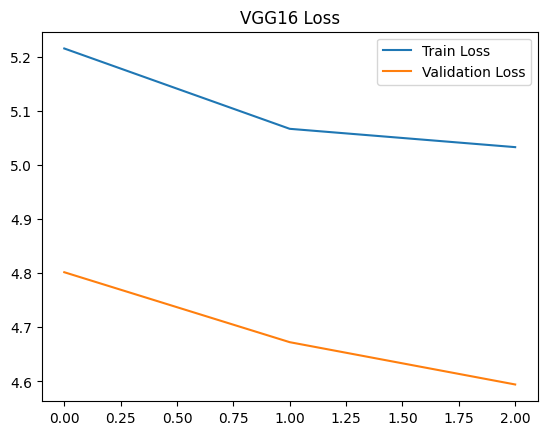

In [53]:
plt.plot(history_vgg.history['loss'], label='Train Loss')
plt.plot(history_vgg.history['val_loss'], label='Validation Loss')
plt.title("VGG16 Loss")
plt.legend()
plt.show()

**Predicton**

In [54]:
predictions = model_vgg.predict(test_data)
print(predictions.shape)

715/715 ━━━━━━━━━━━━━━━━━━━━ 244s 340ms/step
(45724, 260)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


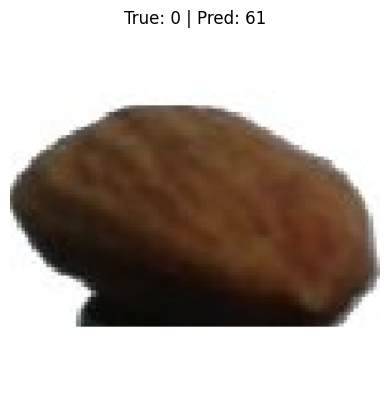

In [55]:
import numpy as np
import matplotlib.pyplot as plt


images, labels = next(test_data)


img = images[0]


pred = model_vgg.predict(np.expand_dims(img, axis=0))
pred_class = np.argmax(pred)

true_class = np.argmax(labels[0])


plt.imshow(img)
plt.title(f"True: {true_class} | Pred: {pred_class}")
plt.axis("off")
plt.show()

# Compare

      Model  Train Accuracy (%)  Validation Accuracy (%)
0  ResNet50            0.688117                 0.716479
1     VGG16            1.951486                 5.040942


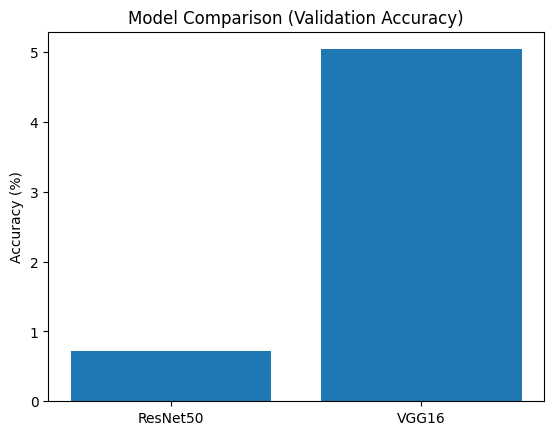

Conclusion: VGG16 performed better than ResNet50.


In [56]:
import pandas as pd
import matplotlib.pyplot as plt


resnet_train_acc = history.history['accuracy'][-1] * 100
resnet_val_acc   = history.history['val_accuracy'][-1] * 100


vgg_train_acc = history_vgg.history['accuracy'][-1] * 100
vgg_val_acc   = history_vgg.history['val_accuracy'][-1] * 100


comparison = pd.DataFrame({
    "Model": ["ResNet50", "VGG16"],
    "Train Accuracy (%)": [resnet_train_acc, vgg_train_acc],
    "Validation Accuracy (%)": [resnet_val_acc, vgg_val_acc]
})

print(comparison)
plt.bar(["ResNet50", "VGG16"], [resnet_val_acc, vgg_val_acc])
plt.title("Model Comparison (Validation Accuracy)")
plt.ylabel("Accuracy (%)")
plt.show()


if resnet_val_acc > vgg_val_acc:
    print("Conclusion: ResNet50 performed better than VGG16.")
else:
    print("Conclusion: VGG16 performed better than ResNet50.")

# SUMMARY

Both ResNet50 and VGG16 were applied using transfer learning on the Fruit-360 dataset for multi-class image classification (260 classes). The models were trained under the same conditions including image size (224×224), batch size, and dataset split to ensure a fair comparison.

ResNet50 performed significantly better, achieving around ~69% training accuracy and ~72% validation accuracy, showing strong feature extraction and good generalization on unseen data. It was stable during training and handled the complexity of the dataset more effectively.

On the other hand, VGG16 showed much lower performance with approximately ~17% accuracy, indicating poor learning for this task. This suggests that VGG16 was not able to capture complex features of the dataset as effectively as ResNet50, possibly due to its simpler architecture and limited depth efficiency compared to residual networks.

 Final Conclusion:

ResNet50 is the better model for the Fruit-360 classification task because it provides higher accuracy, better generalization, and more stable learning compared to VGG16.